# K-Means Clustering & Silhouette Analysis

Selecting the number of clusters $K$ in unsupervised K-Means is a fundamental model selection task. The Silhouette coefficient measures how close each point in one cluster is to points in neighboring clusters (range [-1, 1], higher is better). This notebook generates synthetic clustered coordinates (3 blobs) and calculates Silhouette scores across neighbor sizes $K=2$ to $K=8$ to find the optimal clustering parameters.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Generate synthetic 2D coordinate blobs (3 centers, 300 samples)
np.random.seed(91)
n_samples = 300

centers = [
    [1.5, 2.0],
    [-2.0, -1.0],
    [2.0, -2.0]
]

X_list = []
for center in centers:
    cluster_noise = np.random.normal(0, 0.5, (100, 2))
    X_list.append(center + cluster_noise)

X = np.vstack(X_list)

df = pd.DataFrame(X, columns=['X_Coord', 'Y_Coord'])
df.head(10)



,X_Coord,Y_Coord
0,1.196939,1.470030
1,1.224540,1.862157
2,2.111127,1.547071
3,1.534676,3.089328
4,1.573658,2.258629
5,0.853010,1.472556
6,1.732384,2.117053
7,2.389433,2.431938
8,1.487470,1.921256
9,1.150981,1.914455


## Silhouette Scores Computation Loop

We fit K-Means clustering models for cluster sizes ranging from $K=2$ to $K=8$ and record the resulting Silhouette coefficients.



In [2]:
k_values = range(2, 9)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"Optimal cluster count (K): {optimal_k}")
print(f"Max Silhouette Score:     {max(silhouette_scores):.4f}")



Optimal cluster count (K): 3
Max Silhouette Score:     0.7927


## Silhouette Parameter Curve Plot

Using Matplotlib, we plot the Silhouette scores against values of $K$ to highlight the peak coefficient value that identifies the correct number of coordinate clusters.



<cell>:11: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



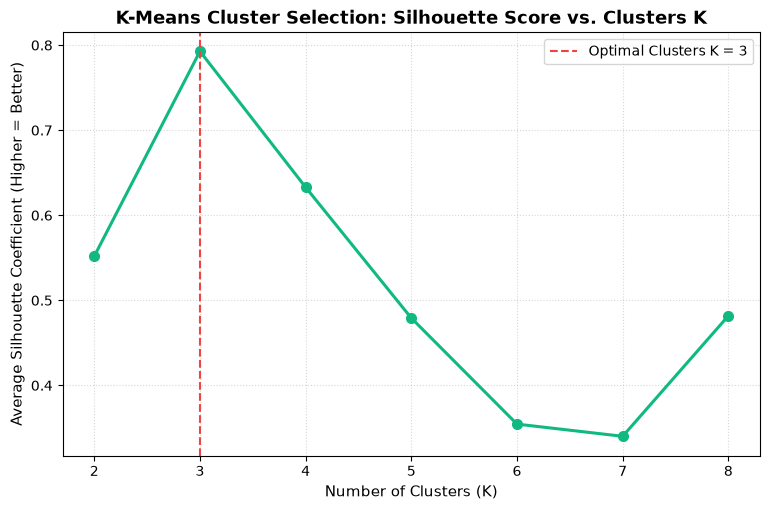

In [3]:
plt.figure(figsize=(9, 5.5))
plt.plot(k_values, silhouette_scores, marker='o', color='#10B981', linewidth=2.2, markersize=7)
plt.axvline(optimal_k, color='#EF4444', linestyle='--', linewidth=1.5, label=f'Optimal Clusters K = {optimal_k}')

plt.title('K-Means Cluster Selection: Silhouette Score vs. Clusters K', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=11)
plt.ylabel('Average Silhouette Coefficient (Higher = Better)', fontsize=11)
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()
